# =====================================================
# Student Dropout Prediction
# =====================================================


## Dataset
The dataset contains demographic, academic, and socioeconomic
information about university students.

Target variable:
- Dropout
- Graduate
- Enrolled (removed for this study)

The goal is to predict whether a student will drop out or graduate.

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("dataset.csv")   # change if your file name is different


## Data Preprocessing



In [19]:
# Remove "Enrolled" students
df = df[df["Target"] != "Enrolled"]

# Convert target to binary
df["Target"] = df["Target"].map({
    "Dropout":1,
    "Graduate":0
})



## Feature Engineering


In [ ]:
df["grade_interaction"] = df["Curricular units 1st sem (grade)"] * df["Curricular units 2nd sem (grade)"]
df["approval_interaction"] = df["Curricular units 1st sem (approved)"] * df["Curricular units 2nd sem (approved)"]
df["grade_per_age"] = df["Curricular units 1st sem (grade)"] / (df["Age at enrollment"] + 1)



In [20]:

selected_columns = df.columns.tolist()
selected_columns.remove("Target")

X = df[selected_columns]
y = df["Target"]

## Train-Test Split


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Model Training
Four machine learning models were trained and compared:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 7. Define Models
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

## Model Evaluation
Models were evaluated using accuracy, confusion matrix,
ROC curve, Precision–Recall curve and cross-validation.

In [23]:
from sklearn.metrics import accuracy_score

results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Gradient Boosting": accuracy_score(y_test, gb_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

for model, score in results.items():
    print(model, "Accuracy:", round(score,4))

Logistic Regression Accuracy: 0.9408
Random Forest Accuracy: 0.9284
Gradient Boosting Accuracy: 0.9339
XGBoost Accuracy: 0.938


In [24]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression\n", confusion_matrix(y_test, lr_pred))
print("\nRandom Forest\n", confusion_matrix(y_test, rf_pred))
print("\nGradient Boosting\n", confusion_matrix(y_test, gb_pred))
print("\nXGBoost\n", confusion_matrix(y_test, xgb_pred))

Logistic Regression
 [[421  21]
 [ 22 262]]

Random Forest
 [[422  20]
 [ 32 252]]

Gradient Boosting
 [[423  19]
 [ 29 255]]

XGBoost
 [[423  19]
 [ 26 258]]


### ROC Curve


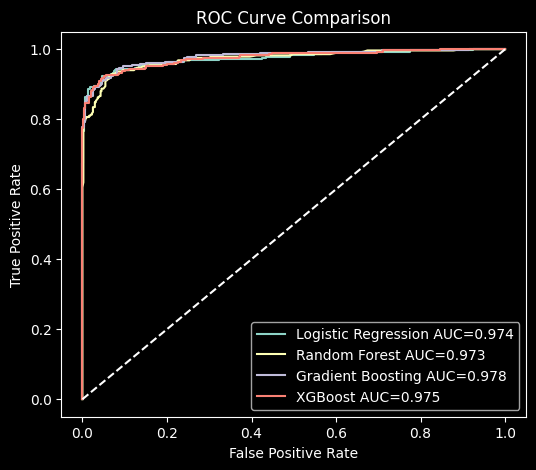

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr_model.predict_proba(X_test_scaled)[:,1],
    "Random Forest": rf_model.predict_proba(X_test)[:,1],
    "Gradient Boosting": gb_model.predict_proba(X_test)[:,1],
    "XGBoost": xgb_model.predict_proba(X_test)[:,1]
}

plt.style.use("dark_background")   # enables dark theme

plt.figure(figsize=(6,5))

for name, probs in models.items():

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, label=name + " AUC=" + str(round(auc,3)))

plt.plot([0,1],[0,1],'--', color="white")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Precision–Recall Curve


In [26]:
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

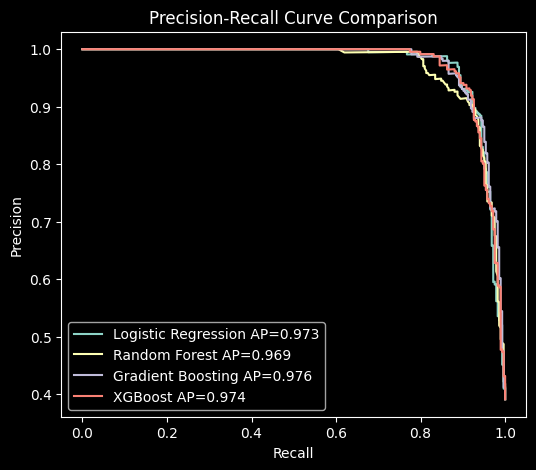

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.style.use("dark_background")  # dark theme

models = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "Gradient Boosting": gb_prob,
    "XGBoost": xgb_prob
}

plt.figure(figsize=(6,5))

for name, probs in models.items():

    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)

    plt.plot(recall, precision, label=name + " AP=" + str(round(ap,3)))

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

In [28]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("\nRandom Forest")
print(classification_report(y_test, rf_pred))

print("\nGradient Boosting")
print(classification_report(y_test, gb_pred))

print("\nXGBoost")
print(classification_report(y_test, xgb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       442
           1       0.93      0.92      0.92       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726


Random Forest
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       442
           1       0.93      0.89      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726


Gradient Boosting
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       442
           1       0.93      0.90      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.93      0.93       726
weighted avg       0

## Cross Validation



In [29]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

for name, model in models.items():

    if name == "Logistic Regression":
        score = cross_val_score(model, scaler.fit_transform(X), y, cv=5)
    else:
        score = cross_val_score(model, X, y, cv=5)

    print(name, "CV Accuracy:", round(score.mean(),4))

Logistic Regression CV Accuracy: 0.9143
Random Forest CV Accuracy: 0.9047
Gradient Boosting CV Accuracy: 0.9107
XGBoost CV Accuracy: 0.9036


## Feature Importance


/tmp/ipykernel_763/2283410460.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


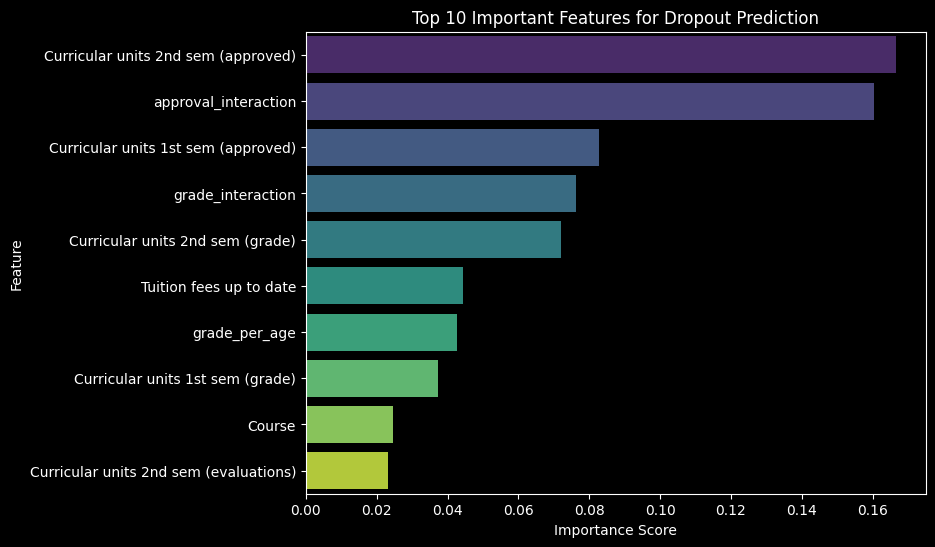

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")   # enable dark theme

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10),
    palette="viridis"
)

plt.title("Top 10 Important Features for Dropout Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [31]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": selected_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance


,Feature,Importance
28,Curricular units 2nd sem (approved),0.166652
35,approval_interaction,0.160378
22,Curricular units 1st sem (approved),0.082660
34,grade_interaction,0.076394
29,Curricular units 2nd sem (grade),0.072164
14,Tuition fees up to date,0.044323
36,grade_per_age,0.042547
23,Curricular units 1st sem (grade),0.037390
3,Course,0.024619
27,Curricular units 2nd sem (evaluations),0.023155


## Conclusion
The models achieved high predictive performance (~94% accuracy).
Academic performance indicators such as approved curricular units
and semester grades were the most influential predictors of dropout.